## imports

In [1]:
#
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist
from scipy.signal import resample
from scipy.stats import zscore, pearsonr, norm, zscore
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns
%matplotlib inline

## set paths

In [2]:
#
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings')
pickle_dir = '../../data/pickles/'
delfig_dir = '../../figures/immediate-delayed-analyses/'

## load data

In [3]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

## define some functions

In [4]:
def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [5]:
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [6]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

In [7]:
def corr_pearsonr(rs1, rs2):
    return _z2r(np.array(pearsonr(_r2z(np.array(rs1)), _r2z(np.array(rs2)))))

In [8]:
def corr_sigdiff_ind(r1n1, r2n2, n_obs1=None, n_obs2=None):
    """
    Function that returns the inverse z-transformed difference 
    difference between two correlation coefficients from independent samples
    of different sizes
    
    Parameters
    ----------
    r1n1 : tup of floats or ndarray
        sample 1's correlation value and number of observations
    r2n2 : tup of floats or ndarray
        sample 2's correlation value and number of observations
    obs1 : int
        if r1n1 and r2n2 are ndarrays, the number of observations that
        went into calculating r1n1
    obs2 : int
        if r1n1 and r2n2 are ndarrays, the number of observations that
        went into calculating r2n2
    
    Returns
    ----------
    coff_diff : float
        difference between correlation coefficients 
    
    """
    if isinstance(r1n1, np.ndarray) and isinstance(r2n2, np.ndarray):
        Z_diff = (_r2z(r1n1) - _r2z(r2n2)) / np.sqrt(1/(n_obs1-3) + 1/(n_obs2-3))
        
    
    elif isinstance(r1n1, tuple) and isinstance(r2n2, tuple):
        r1, n1 = r1n1
        r2, n2 = r2n2
        Z_diff = _z2r((_r2z(r1) - _r2z(r2)) / np.sqrt(1/(n1-3) + 1/(n2-3)))
    
    else:
        raise ValueError("both arguments must be the same type")
        
    return (Z_diff, norm.sf(abs(Z_diff))*2)

In [9]:
def ribbon(M, color='k', alpha=0.5, label=None):
    # for plotting 95% CI bars
    x = np.arange(M.shape[0])
    y = np.mean(M, axis=1)
    ci = 1.96 * np.divide(np.std(M, axis=1), np.sqrt(M.shape[1] - 1))
    
    h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color, label=label)
    return h1, h2

## compare variance among participants for immediate and delayed recall

In [10]:
# immediate recall-episode correlation at each timepoint
imm_trajs = [traj for turkid, traj in participant_trajectories['atlep1']]
sub_corrs_i = np.empty((59, 1466))

for ix, sub_traj in enumerate(imm_trajs):
    sub_corrs_i[ix] = np.diag(1-cdist(avg_participant_trajectories['atlep1'], sub_traj, metric='correlation'))
    
immediate_var_c = corr_mean(sub_corrs_i, axis=0)

In [12]:
# delayed recall-episode correlation at each timepoint
del_trajs = [traj for turkid, traj in participant_trajectories['delayed']]
sub_corrs_d = np.empty((59, 1466))

for ix, sub_traj in enumerate(del_trajs):
    sub_corrs_d[ix] = np.diag(1-cdist(avg_participant_trajectories['delayed'], sub_traj, metric='correlation'))
    
delayed_var_c = corr_mean(sub_corrs_d, axis=0)

In [34]:
sub_corrs_d.T[:-200].shape

(1266, 59)

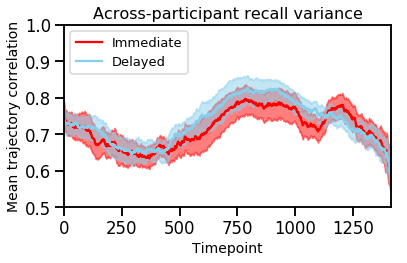

In [59]:
sns.set_context('talk')
ribbon(sub_corrs_i.T[:-50], color='red', label='Immediate')
ribbon(sub_corrs_d.T[:-50], color='skyblue', label='Delayed')
plt.xlim((0,1416))
plt.ylim((0.5,1))
plt.title('Across-participant recall variance', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Mean trajectory correlation', fontsize=14)
plt.legend(loc=2, fontsize=13)
plt.tight_layout()
# plt.savefig(delfig_dir+'immediate-delayed-variance-corr.pdf')

In [15]:
# # immediate episode-recall distance at each timepoint
# sub_dists_i = np.empty((59, 1466))

# for ix, sub_traj in enumerate(imm_trajs):
#     sub_dists_i[ix] = np.diag(cdist(avg_participant_trajectories['atlep1'], sub_traj, metric='euclidean'))
    
# immediate_var_d = np.mean(sub_dists_i, axis=0)

In [16]:
# # immediate episode-recall distance at each timepoint
# sub_dists_d = np.empty((59, 1466))

# for ix, sub_traj in enumerate(del_trajs):
#     sub_dists_d[ix] = np.diag(cdist(avg_participant_trajectories['delayed'], sub_traj, metric='euclidean'))
    
# delayed_var_d = np.mean(sub_dists_d, axis=0)

In [21]:
# ribbon(sub_dists_i.T, color='red', label='Immediate')
# ribbon(sub_dists_d.T, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# plt.title('Across-participant recall variance', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Variance', fontsize=14)
# plt.legend(loc=3, fontsize=14)
# plt.tight_layout()
# # plt.savefig(delfig_dir+'immediate-delayed-variance-dist.pdf')

## compare episode-recall distance for each timepoint between immediate and delayed recall

### first with euclidean distance

In [22]:
# immediate_distance = np.diag(cdist(avg_participant_trajectories['atlep1'], episode_trajectories['atlep1'], 
#                                    metric='euclidean'))
# delayed_distance = np.diag(cdist(avg_participant_trajectories['delayed'], episode_trajectories['atlep1'], 
#                                    metric='euclidean'))

In [23]:
# plt.plot(immediate_distance, color='red', label='Immediate')
# plt.plot(delayed_distance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# #plt.ylim((0.25,0.58))
# plt.title('Episode-recall distance by timepoint', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Euclidean distance', fontsize=14)
# plt.legend(fontsize=14)
# # plt.savefig(delfig_dir+'immediate-delayed-ep-rec-euc-dist.pdf')

### repeat with trajectory correlation

In [24]:
immediate_corr = np.diag(1-cdist(avg_participant_trajectories['atlep1'], episode_trajectories['atlep1'], 
                                   metric='correlation'))
delayed_corr = np.diag(1-cdist(avg_participant_trajectories['delayed'], episode_trajectories['atlep1'], 
                                   metric='correlation'))

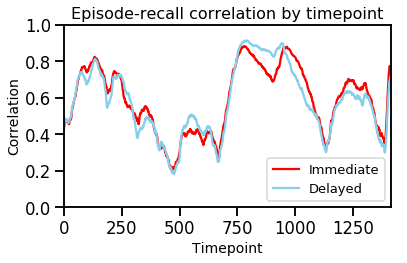

In [62]:
sns.set_context('talk')
plt.plot(immediate_corr[:-50], color='red', label='Immediate')
plt.plot(delayed_corr[:-50], color='skyblue', label='Delayed')
plt.xlim((0,1416))
plt.ylim((0,1))
plt.title('Episode-recall correlation by timepoint', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Correlation', fontsize=14)
plt.legend(fontsize=13)
plt.tight_layout()
# plt.savefig(delfig_dir+'immediate-delayed-ep-rec-corr.pdf')

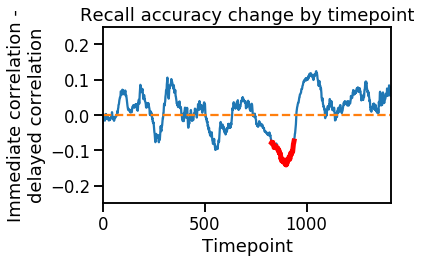

In [88]:
sns.set_context('talk')
corr_diff = immediate_corr[:-50]-delayed_corr[:-50]
sigdiffs = corr_sigdiff_ind(delayed_corr[:-50], immediate_corr[:-50], 100, 100)
sigmask = np.ma.masked_where(sigdiffs[1]>=0.05, corr_diff)
plt.plot(corr_diff)
plt.plot([0,1416], [0,0], linestyle='--')
plt.plot(np.ma.filled(sigmask, fill_value=np.nan), linewidth=5, color='red')
plt.xlim((0,1416))
plt.ylim((-.25,.25))
plt.xlabel('Timepoint')
plt.ylabel('Immediate correlation -\ndelayed correlation')
plt.title('Recall accuracy change by timepoint')
plt.tight_layout()
# plt.savefig(delfig_dir+'accuracy_diff_by_tpt.pdf')

## what event falls during these timepoints

### (to do later)

## try with sherlock-proportional episode windows

In [16]:
# ep_prop_traj_dir = os.path.join(ep_model_dir, 't100_wProp', 'trajectories')
# rec_prop_traj_dir = os.path.join(rec_traj_dir, 'vidwProp')

# # episode trajectories
# episode_trajectories_prop = {episode : np.load(os.path.join(ep_prop_traj_dir, episode+'_model_t100_wProp_res.npy')) 
#                         for episode in ['atlep1','atlep2','arrdev']}

# # individual participant trajectories
# participant_trajectories_prop = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

# for root, dirs, files in os.walk(rec_prop_traj_dir):
#     traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
#     for f_name in traj_models:
#         t = np.load(os.path.join(root,f_name))
#         participant_trajectories_prop[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# # average participant trajectories
# avg_participant_trajectories_prop = {rectype : np.load(os.path.join(rec_prop_traj_dir, rectype, 
#                                                                     'avg_trajectory.npy')) 
#                                      for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

In [17]:
# imm_trajs = [traj for turkid, traj in participant_trajectories_prop['atlep1']]
# sub_dists_i = []

# for traj in imm_trajs:
#     sub_dists_i.append(np.diag(cdist(avg_participant_trajectories_prop['atlep1'], traj, metric='euclidean')))

# immediate_variance = np.mean(sub_dists_i, axis=0)

In [18]:
# del_trajs = [traj for turkid, traj in participant_trajectories_prop['delayed']]
# sub_dists_d = []

# for traj in del_trajs:
#     sub_dists_d.append(np.diag(cdist(avg_participant_trajectories_prop['delayed'], traj, metric='euclidean')))

# delayed_variance = np.mean(sub_dists_d, axis=0)

In [19]:
# plt.plot(immediate_variance, color='red', label='Immediate')
# plt.plot(delayed_variance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# plt.ylim((0.25,0.58))
# plt.title('Participant trajectory variability', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Variance', fontsize=14)
# plt.legend(loc=2, fontsize=14)

# plt.tight_layout()
# #plt.savefig('../../figures/immediate-delayed-variance.pdf')

In [20]:
# immediate_distance = np.diag(cdist(avg_participant_trajectories_prop['atlep1'], episode_trajectories_prop['atlep1'], 
#                                    metric='euclidean'))
# delayed_distance = np.diag(cdist(avg_participant_trajectories_prop['delayed'], episode_trajectories_prop['atlep1'], 
#                                    metric='euclidean'))

In [21]:
# plt.plot(immediate_distance, color='red', label='Immediate')
# plt.plot(delayed_distance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# #plt.ylim((0.25,0.58))
# plt.title('Episode-recall distance by timepoint', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Euclidean distance', fontsize=14)
# plt.legend(fontsize=14)
# #plt.savefig('../../figures/immediate-delayed-ep-rec-euc-dist.pdf')

In [22]:
# immediate_distance = np.diag(1-cdist(avg_participant_trajectories_prop['atlep1'], episode_trajectories_prop['atlep1'], 
#                                    metric='correlation'))
# delayed_distance = np.diag(1-cdist(avg_participant_trajectories_prop['delayed'], episode_trajectories_prop['atlep1'], 
#                                    metric='correlation'))

In [23]:
# plt.plot(immediate_distance, color='red', label='Immediate')
# plt.plot(delayed_distance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# plt.ylim((0,1))
# plt.title('Episode-recall correlation by timepoint', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Correlation', fontsize=14)
# plt.legend(fontsize=14)
# #plt.savefig('../../figures/immediate-delayed-ep-rec-corr.pdf')

In [24]:
# for i, rectype in enumerate(participant_trajectories.keys()):
#     test = [traj for turkid, traj in participant_trajectories[rectype]]
#     plt.subplot(2,3,i+1)
#     plt.plot(np.mean(np.var(test, axis=0), axis=1))
#     plt.title(rectype)
    
# plt.tight_layout()
# plt.savefig('/Users/paxtonfitzpatrick/Desktop/variances')

# compare by events

In [89]:
ep_events = episode_events['atlep1']
imm_events = participant_events['atlep1']
del_events = participant_events['delayed']
imm_matches = event_mappings['atlep1']
del_matches = event_mappings['delayed']

## compare total number of events per participant

In [90]:
n_events = dict.fromkeys(id_maps.keys())

for sid in n_events.keys():
    tid1, n_es1  = next((tid, len(es)) for tid, es in imm_matches if tid == id_maps[sid]['session 1'])
    tid2, n_es2 = next((tid, len(es)) for tid, es in del_matches if tid == id_maps[sid]['session 2'])
    n_events[sid] = (n_es1, n_es2)

In [91]:
print(np.mean([ne[0] for ne in n_events.values()]))
print(np.mean([ne[1] for ne in n_events.values()]))
print(np.mean([ne[0] for ne in n_events.values()]) - np.mean([ne[1] for ne in n_events.values()]))

17.389830508474578
14.203389830508474
3.186440677966104


## compare total number of UNIQUE events per participant

In [92]:
n_unique_events = dict.fromkeys(id_maps.keys())

for sid in n_unique_events.keys():
    tid1, n_ues1  = next((tid, len(np.unique(es))) for tid, es in imm_matches if tid == id_maps[sid]['session 1'])
    tid2, n_ues2 = next((tid, len(np.unique(es))) for tid, es in del_matches if tid == id_maps[sid]['session 2'])
    n_unique_events[sid] = (n_ues1, n_ues2)

In [93]:
print(np.mean([ne[0] for ne in n_unique_events.values()]))
print(np.mean([ne[1] for ne in n_unique_events.values()]))
print(np.mean([ne[0] for ne in n_unique_events.values()]) - np.mean([ne[1] for ne in n_unique_events.values()]))

11.40677966101695
9.64406779661017
1.7627118644067803


## compare distance from each recall event to corresponding episode event

### (closest matched event)

In [30]:
# multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_dist','del_dist','diff']], 
#                                         names=['event', 'distance'])
# event_match_distances = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

# # for each subject
# for sid in event_match_distances.columns:
    
#     sub_i_ds = []
#     sub_d_ds = []
#     sub_diffs = []
        
#     # get their immediate and delayed recall events and matches
#     sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
#     sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
#     sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
#     sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

#     # for each episode event
#     for i, ep_e in enumerate(ep_events):
#         # if the subject recalled that event
#         if i in sub_i_ms and i in sub_d_ms:
#             # find the distance between the episode event and closest matching recalled event
#             mindist_i = np.min(cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='euclidean'))
#             mindist_d = np.min(cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='euclidean'))
#             mindist_diff = mindist_d - mindist_i
            
#             event_match_distances.at[(i, 'imm_dist'), sid] = mindist_i
#             event_match_distances.at[(i, 'del_dist'), sid] = mindist_d
#             event_match_distances.at[(i, 'diff'), sid] = mindist_diff
            
#             sub_i_ds.append(mindist_i)
#             sub_d_ds.append(mindist_d)
#             sub_diffs.append(mindist_diff)
    
#     # get subject averages across events
#     event_match_distances.at[('average','imm_dist'), sid] = np.mean(sub_i_ds)
#     event_match_distances.at[('average','del_dist'), sid] = np.mean(sub_d_ds)
#     event_match_distances.at[('average','diff'), sid] = np.mean(sub_diffs)
    
#     # subject's across-events average percent difference between distances 
#     event_match_distances.at['avg_percent_diff', sid] = np.mean(sub_diffs) / np.mean(sub_i_ds) 
            
# event_match_distances.dropna(how='all', inplace=True)
# event_match_distances.index = event_match_distances.index.remove_unused_levels()

# # across-subject averages for each event
# event_match_distances['average'] = event_match_distances.mean(axis=1)

# # event's across-subject average percent difference
# for row in event_match_distances.index.levels[0][:-1]:
#     a_p_d = event_match_distances.at[(row, 'diff'), 'average'] / \
#     event_match_distances.at[(row, 'imm_dist'), 'average']
    
#     event_match_distances.at[(row, 'diff'), 'avg_percent_diff'] = a_p_d

In [31]:
# # for each event, relate distance to RAW information loss (raw distance increase)

# sns.jointplot(event_match_distances['average'].loc[:, 'imm_dist'][:-1], 
#             event_match_distances['average'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event distance')
# plt.ylabel('Distance increase immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-best-euclidean-events.pdf')

In [32]:
# # for each event, relate distance to PERCENT information loss (percent distance increase)

# sns.jointplot(event_match_distances['average'].loc[:, 'imm_dist'][:-1], 
#             event_match_distances['avg_percent_diff'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event distance')
# plt.ylabel('Percent distance increase immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-best-euclidean-events.pdf')

In [33]:
# # for each participant, relate average distance to RAW information loss (percent distance increase)

# sns.jointplot(pd.Series(event_match_distances.loc[('average', 'imm_dist')][:-2], dtype='float'), 
#             pd.Series(event_match_distances.loc[('average', 'diff')][:-2], dtype='float'), kind='reg', 
#           stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event distance')
# plt.ylabel('Average distance increase immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-best-euclidean-subs.pdf')

In [34]:
# # for each participant, relate average distance to PERCENT information loss (percent distance increase)

# sns.jointplot(pd.Series(event_match_distances.loc[('average', 'imm_dist')][:-2], dtype='float'), 
#             pd.Series(event_match_distances.loc['avg_percent_diff'].iloc[0][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event distance')
# plt.ylabel('Average percent distance increase immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-best-euclidean-subs.pdf')

### relate event memorability to across-subject variability in memory accuracy

In [35]:
# i_memorability = event_match_distances.loc[pd.IndexSlice[:, 'imm_dist'],'average'][:-1]
# d_memorability = event_match_distances.loc[pd.IndexSlice[:, 'del_dist'],'average'][:-1]

# ev_meandev_i = []
# ev_meandev_d = []
# for ix, event in enumerate(event_match_distances.index.levels[0][:-2]):
    
#     ev_meandev_i.append(np.nanmean([event_match_distances.loc[(event, 'imm_dist'),sub] - i_memorability[event][0] 
#                              for sub in event_match_distances.columns[:-2]]))
#     ev_meandev_d.append(np.nanmean([event_match_distances.loc[(event, 'del_dist'),sub] - d_memorability[event][0] 
#                              for sub in event_match_distances.columns[:-2]]))

In [36]:
# sns.jointplot(i_memorability.tolist(), ev_meandev_i, kind='reg', stat_func=pearsonr)

In [37]:
# sns.regplot(d_memorability.tolist(), ev_meandev_d)

In [38]:
# sns.regplot(i_memorability.tolist(), d_memorability.tolist())

In [39]:
# sns.regplot(ev_meandev_i, ev_meandev_d)

### is number of events recalled related to memory ability?

In [40]:
# n_imm_es = []
# n_del_es = []
# n_diff_es = []
# avg_imm_dist = []
# avg_del_dist = []
# avg_dist_diff = []
# avg_prop_diff = []

# for sid, (imm_n, del_n) in n_events.items():
#     n_imm_es.append(imm_n)
#     n_del_es.append(del_n)
#     n_diff_es.append(imm_n - del_n)
#     avg_imm_dist.append(event_match_distances.at[('average','imm_dist'), sid])
#     avg_del_dist.append(event_match_distances.at[('average','del_dist'), sid])
#     avg_dist_diff.append(event_match_distances.at[('average','diff'), sid])
#     avg_prop_diff.append(event_match_distances.at[('avg_percent_diff',), sid][0])

In [41]:
# # PER SUBJECT number of events recalled vs average episode-recall event distance

# sns.jointplot(n_imm_es, avg_imm_dist, kind='reg', stat_func=pearsonr)
# plt.xlabel('Number of events immediately recalled')
# plt.ylabel('Average episode-recall event distance')
# plt.suptitle('Number of events vs event accuracy', y=1.05)

In [42]:
# # PER SUBJECT number of events immediately recalled vs number of events recalled after delay

# sns.jointplot(n_imm_es, n_del_es, kind='reg', stat_func=pearsonr)
# plt.xlabel('Number of events immediately recalled')
# plt.ylabel('Number of events recalled after delay')
# plt.suptitle('Immediate recall events vs delayed recall events', y=1.05)
# plt.savefig(delfig_dir+'n-events-imm-del.pdf')

In [43]:
# # PER SUBJECT average immediate recall event accuracy vs avreage delayed recall accuracy

# sns.jointplot(avg_imm_dist, avg_del_dist, kind='reg', stat_func=pearsonr)
# plt.xlabel('Average immediate episode-recall event distance')
# plt.ylabel('Average delayed episode-recall event distance')
# plt.suptitle('Immediate event accuracy vs delayed event accuracy', y=1.05)
# plt.savefig(delfig_dir+'imm-del-avg-event-dist.pdf')

In [44]:
# # PER SUBJECT decrease in number of events remembered vs proportional increase in distance

# sns.jointplot(n_del_es, avg_dist_diff, kind='reg', stat_func=pearsonr)
# plt.xlabel('Number of events forgotten during delay')
# plt.ylabel('Proportional decrease in event memory accuracy')
# plt.suptitle('Immediate event accuracy vs delayed event accuracy', y=1.05)
# #plt.savefig(delfig_dir+'imm-del-avg-event-dist.pdf')

### (average of matched events)

In [45]:
# multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_dist','del_dist','diff']], 
#                                         names=['event', 'distance'])
# event_match_distances = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

# for sid in event_match_distances.columns:
    
#     sub_i_ds = []
#     sub_d_ds = []
#     sub_diffs = []
        
#     # get participant's immediate and delayed recall events and matches
#     sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
#     sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
#     sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
#     sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

#     # for each episode event
#     for i, ep_e in enumerate(ep_events):
#         # if the subject recalled that event
#         if i in sub_i_ms and i in sub_d_ms:
#             # find the distance between the episode event and closest matching recalled event
#             avgdist_i = np.mean(cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='euclidean'))
#             avgdist_d = np.mean(cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='euclidean'))
#             avgdist_diff = avgdist_d - avgdist_i
            
#             event_match_distances.at[(i, 'imm_dist'), sid] = avgdist_i
#             event_match_distances.at[(i, 'del_dist'), sid] = avgdist_d
#             event_match_distances.at[(i, 'diff'), sid] = avgdist_diff
            
#             sub_i_ds.append(avgdist_i)
#             sub_d_ds.append(avgdist_d)
#             sub_diffs.append(avgdist_diff)
            
#     event_match_distances.at[('average','imm_dist'), sid] = np.mean(sub_i_ds)
#     event_match_distances.at[('average','del_dist'), sid] = np.mean(sub_d_ds)
#     event_match_distances.at[('average','diff'), sid] = np.mean(sub_diffs)
    
#     event_match_distances.at['avg_percent_diff', sid] = np.mean(sub_diffs) / np.mean(sub_i_ds) 

            
# event_match_distances.dropna(how='all', inplace=True)
# event_match_distances.index = event_match_distances.index.remove_unused_levels()

# event_match_distances['average'] = event_match_distances.mean(axis=1)

# for row in event_match_distances.index.levels[0][:-1]:
#     a_p_d = event_match_distances.at[(row, 'diff'), 'average'] / \
#     event_match_distances.at[(row, 'imm_dist'), 'average']
    
#     event_match_distances.at[(row, 'diff'), 'avg_percent_diff'] = a_p_d

In [46]:
# # RAW distance increase by event
# sns.jointplot(event_match_distances['average'].loc[:, 'imm_dist'][:-1], 
#             event_match_distances['average'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event distance')
# plt.ylabel('Distance increase immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-mean-euclidean-events.pdf')

In [47]:
# # PERCENT distance increase by event
# sns.jointplot(event_match_distances['average'].loc[:, 'imm_dist'][:-1], 
#             event_match_distances['avg_percent_diff'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event distance')
# plt.ylabel('Percent distance increase immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-mean-euclidean-events.pdf')

In [48]:
# # RAW distance increase  by subject

# sns.jointplot(pd.Series(event_match_distances.loc[('average', 'imm_dist')][:-2], dtype='float'), 
#             pd.Series(event_match_distances.loc[('average', 'diff')][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event distance')
# plt.ylabel('Average distance increase immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-mean-euclidean-subs.pdf')

In [49]:
# # PERCENT distance increase by subject
# sns.jointplot(pd.Series(event_match_distances.loc[('average', 'imm_dist')][:-2], dtype='float'), 
#             pd.Series(event_match_distances.loc['avg_percent_diff'].iloc[0][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event distance')
# plt.ylabel('Average percent distance increase immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-mean-euclidean-subs.pdf')

In [50]:
# # repeat event memorability vs accross-subject variability in memory accuracy analysis
# i_memorability = event_match_distances.loc[pd.IndexSlice[:, 'imm_dist'],'average'][:-1]
# d_memorability = event_match_distances.loc[pd.IndexSlice[:, 'del_dist'],'average'][:-1]

# ev_meandev_i = []
# ev_meandev_d = []
# for ix, event in enumerate(event_match_distances.index.levels[0][:-2]):
    
#     ev_meandev_i.append(np.nanmean([event_match_distances.loc[(event, 'imm_dist'),sub] - i_memorability[event][0] 
#                              for sub in event_match_distances.columns[:-2]]))
#     ev_meandev_d.append(np.nanmean([event_match_distances.loc[(event, 'del_dist'),sub] - d_memorability[event][0] 
#                              for sub in event_match_distances.columns[:-2]]))

In [51]:
# sns.regplot(i_memorability.tolist(), ev_meandev_i)

In [52]:
# sns.regplot(d_memorability.tolist(), ev_meandev_d)

In [53]:
# sns.regplot(i_memorability.tolist(), d_memorability.tolist())

In [54]:
# sns.regplot(ev_meandev_i, ev_meandev_d)

## compare topic vector correlation between each recall event and corresponding episode event

### (matched event with highest correlation)

In [94]:
multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_corr','del_corr','diff']], 
                                        names=['event', 'correlation'])
event_match_corrs = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

for sid in event_match_corrs.columns:
    
    sub_i_cs = []
    sub_d_cs = []
    sub_diffs = []
        
    # get participant's immediate and delayed recall events and matches
    sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
    sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
    sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
    sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

    # for each episode event
    for i, ep_e in enumerate(ep_events):
        # if the subject recalled that event
        if i in sub_i_ms and i in sub_d_ms:
            # compute the correlation between the episode event and most highly correlated matching recalled event
            maxcorr_i = np.max(1-cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='correlation'))
            maxcorr_d = np.max(1-cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='correlation'))
            maxcorr_diff = maxcorr_d - maxcorr_i
            
            event_match_corrs.at[(i, 'imm_corr'), sid] = maxcorr_i
            event_match_corrs.at[(i, 'del_corr'), sid] = maxcorr_d
            event_match_corrs.at[(i, 'diff'), sid] = maxcorr_diff
            
            sub_i_cs.append(maxcorr_i)
            sub_d_cs.append(maxcorr_d)
            sub_diffs.append(maxcorr_diff)
            
    event_match_corrs.at[('average','imm_corr'), sid] = corr_mean(sub_i_cs)
    event_match_corrs.at[('average','del_corr'), sid] = corr_mean(sub_d_cs)
    event_match_corrs.at[('average','diff'), sid] = corr_mean(sub_diffs)
    
    event_match_corrs.at['avg_percent_diff', sid] = corr_mean(sub_diffs) / corr_mean(sub_i_cs)
            
event_match_corrs.dropna(how='all', inplace=True)
event_match_corrs.index = event_match_corrs.index.remove_unused_levels()

#event_match_corrs = event_match_corrs.astype('float64')
event_match_corrs['average'] = corr_mean(event_match_corrs.astype('float64').values, axis=1)

for row in event_match_corrs.index.levels[0][:-1]:
    a_p_d = event_match_corrs.at[(row, 'diff'), 'average'] / event_match_corrs.at[(row, 'imm_corr'), 'average']
    
    event_match_corrs.at[(row, 'diff'), 'avg_percent_diff'] = a_p_d

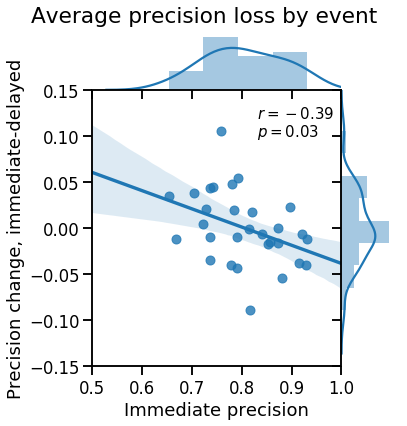

In [204]:
# # for each EVENT, relate distance to RAW information loss (raw correlation decrease)

# sns.set_context('talk')
sns.jointplot(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], 
            event_match_corrs['average'].loc[:, 'diff'][:-1], kind='reg', space=0, xlim=(0.5,1), ylim=(-.15,.15))
r,p = pearsonr(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], event_match_corrs['average'].loc[:, 'diff'][:-1])
r,p = str(round(r, 2)), str(round(p, 2))
plt.text(.83,0.12, f'$r={r}$', ha='left', fontsize=15)   
plt.text(.83,0.1, f'$p={p}$', ha='left', fontsize=15)
plt.xlabel('Immediate precision')
plt.ylabel('Precision change, immediate-delayed')
plt.suptitle('Average precision loss by event', y=1)
# plt.tight_layout()
# plt.savefig(delfig_dir+'delay-loss-raw-best-corr-events.pdf')

In [177]:
# # for each event, relate distance to PERCENT information loss (percent correlation decrease)

# sns.jointplot(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], 
#             event_match_corrs['avg_percent_diff'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event correlation')
# plt.ylabel('Percent correlation change immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-best-corr-events.pdf')

1.804320658910059e-05


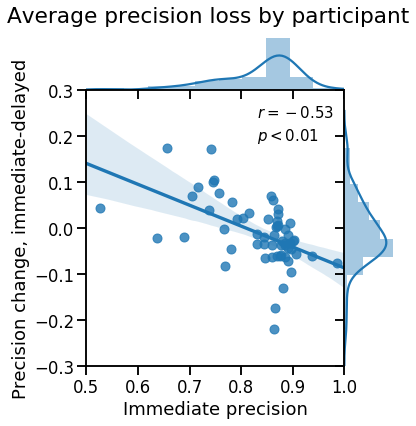

In [201]:
# for each PARTICIPANT, relate average correlation to RAW information loss (raw correlation decrease)

sns.jointplot(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
            pd.Series(event_match_corrs.loc[('average', 'diff')][:-2], dtype='float'), kind='reg', space=0, 
              xlim=(0.5,1), ylim=(-.3,.3))
r,p = pearsonr(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
            pd.Series(event_match_corrs.loc[('average', 'diff')][:-2], dtype='float'))
print(p)
r = str(round(r, 2))
p = 0.01
plt.text(.83,0.24, f'$r={r}$', ha='left', fontsize=15)   
plt.text(.83,0.19, f'$p<{p}$', ha='left', fontsize=15)
plt.xlabel('Immediate precision')
plt.ylabel('Precision change, immediate-delayed')
plt.suptitle('Average precision loss by participant', y=1)
# plt.savefig(delfig_dir+'delay-loss-raw-best-corr-subs.pdf')

In [179]:
# # for each participant, relate average correlation to PERCENT information loss (percent correlation decrease)

# sns.jointplot(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
#             pd.Series(event_match_corrs.loc['avg_percent_diff'].iloc[0][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event correlation')
# plt.ylabel('Average percent correlation change immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-best-corr-subs.pdf')

### (average of matched events)

In [34]:
multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_corr','del_corr','diff']], 
                                        names=['event', 'correlation'])
event_match_corrs = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

for sid in event_match_corrs.columns:
    
    sub_i_cs = []
    sub_d_cs = []
    sub_diffs = []
        
    # get participant's immediate and delayed recall events and matches
    sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
    sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
    sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
    sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

    # for each episode event
    for i, ep_e in enumerate(ep_events):
        # if the subject recalled that event
        if i in sub_i_ms and i in sub_d_ms:
            # compute the correlation between the episode event and most highly correlated matching recalled event
            meancorr_i = corr_mean(1-cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='correlation'), axis=1)[0]
            meancorr_d = corr_mean(1-cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='correlation'), axis=1)[0]
            meancorr_diff = meancorr_d - meancorr_i
            
            event_match_corrs.at[(i, 'imm_corr'), sid] = meancorr_i
            event_match_corrs.at[(i, 'del_corr'), sid] = meancorr_d
            event_match_corrs.at[(i, 'diff'), sid] = meancorr_diff
            
            sub_i_cs.append(meancorr_i)
            sub_d_cs.append(meancorr_d)
            sub_diffs.append(meancorr_diff)
            
    event_match_corrs.at[('average','imm_corr'), sid] = corr_mean(sub_i_cs)
    event_match_corrs.at[('average','del_corr'), sid] = corr_mean(sub_d_cs)
    event_match_corrs.at[('average','diff'), sid] = corr_mean(sub_diffs)
    
    event_match_corrs.at['avg_percent_diff', sid] = corr_mean(sub_diffs) / corr_mean(sub_i_cs)

event_match_corrs.dropna(how='all', inplace=True)
event_match_corrs.index = event_match_corrs.index.remove_unused_levels()

event_match_corrs['average'] = corr_mean(event_match_corrs.astype('float64').values, axis=1)

for row in event_match_corrs.index.levels[0][:-1]:
    a_p_d = event_match_corrs.at[(row, 'diff'), 'average'] / event_match_corrs.at[(row, 'imm_corr'), 'average']
    
    event_match_corrs.at[(row, 'diff'), 'avg_percent_diff'] = a_p_d

In [205]:
# # for each event, relate distance to RAW information loss (raw correlation decrease)

# sns.jointplot(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], 
#             event_match_corrs['average'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event correlation')
# plt.ylabel('Correlation change immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-mean-corr-events.pdf')

In [206]:
# # for each event, relate distance to PERCENT information loss (percent correlation decrease)

# sns.jointplot(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], 
#             event_match_corrs['avg_percent_diff'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event correlation')
# plt.ylabel('Percent correlation change immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-mean-corr-events.pdf')

In [207]:
# # for each participant, relate average correlation to RAW information loss (raw correlation decrease)

# sns.jointplot(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
#             pd.Series(event_match_corrs.loc[('average', 'diff')][:-2], dtype='float'), kind='reg', 
#           stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event correlation')
# plt.ylabel('Average correlation change immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-mean-corr-subs.pdf')

In [208]:
# # for each participant, relate average correlation to PERCENT information loss (percent correlation decrease)

# sns.jointplot(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
#             pd.Series(event_match_corrs.loc['avg_percent_diff'].iloc[0][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event correlation')
# plt.ylabel('Average percent correlation change immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-mean-corr-subs.pdf')